# 실습 5-3 : Trace Data 처리

#### **<실습 내용>**

1. Trace Data의 구조 이해

2. 데이터 전처리

3. Trace Data → 머신러닝 입력 데이터 변환
- 요약 통계량 (Summary Statistics) 후보
- 전체 구간 요약 (Simple Summary)
- 구간별 요약 (Step-based Summary)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day5-3_data.csv", index_col=0)
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (15480, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.0,751.0,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.0,751.0,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.0,751.0,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.0,751.0,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.0,751.0,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000


In [3]:
data.tail()

,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
128,5.0,751.226891,753.226891,131.680672,0.000000,594.319328,101.546218,1227.000000,9367.378151,8886.117647,1243.840336,26.000000,16283.21008,18851.73109,-327.117647,16464.92437,342.989864,0.000000,28398.36975,51.0
128,5.0,751.579832,752.420168,132.739496,0.000000,592.680672,101.420168,1227.000000,9354.798319,8904.319328,1330.941176,26.579832,16241.53782,18888.78992,121.445378,16491.39496,350.653729,0.000000,28354.95798,51.0
128,5.0,752.000000,752.773109,134.386555,0.386555,591.000000,101.000000,1226.226891,9392.243697,8877.008403,826.369748,26.613445,16402.91597,18931.78151,518.302521,16550.38655,354.603309,0.000000,28343.76471,51.0
128,5.0,752.000000,753.806723,135.000000,0.806723,591.579832,100.806723,1225.386555,9427.411765,8839.890756,297.428571,26.000000,16576.21849,18962.70588,553.310924,16583.79832,351.729360,0.193277,28324.18487,51.0
128,5.0,752.000000,753.000000,135.000000,0.000000,594.000000,100.000000,1227.000000,9354.000000,8877.000000,750.000000,26.000000,16598.00000,18974.00000,300.000000,16416.00000,352.536083,1.000000,28350.00000,51.0


---

## 1) Trace Data의 구조 이해

- 129개의 웨이퍼에 대해 공정 진행 과정에서 120개의 측정 포인트마다 19개의 센서 값을 기록한 데이터임
- 데이터는 (129, 120, 19) 형태의 3차원 Trace Data로 구성됨

In [4]:
# 제품(웨이퍼) 수 확인

print("제품 수:", len(data.index.unique()))  # index 고유값 수 = 고유 제품(웨이퍼) 수
print("변수 수:", data.shape[1])              # 전체 컬럼(feature) 개수

제품 수: 129
변수 수: 20


In [5]:
# 0번 웨이퍼의 데이터 확인
print("0번 웨이퍼 데이터 크기:", data.loc[0].shape)  # index가 0인 행(들)의 shape 확인
data.loc[0]  # index가 0인 데이터 출력

0번 웨이퍼 데이터 크기: (120, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.000000,751.000000,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.000000,751.000000,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.000000,751.000000,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.000000,751.000000,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.000000,751.000000,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,5.000000,752.000000,754.000000,132.268908,0.0,1023.268908,100.731092,1184.268908,9436.537815,9038.680672,475.537815,21.000000,16913.10924,19295.22689,484.991597,16387.07563,350.731092,0.0,27937.19328,50.000000
0,5.000000,752.000000,753.798319,133.403361,0.0,1023.394958,100.000000,1185.000000,9439.613445,8982.840336,209.016807,21.000000,16994.63866,19305.61345,537.630252,16392.01681,348.991597,0.0,27862.11765,50.000000
0,5.000000,751.865546,753.000000,134.865546,0.0,1020.865546,100.000000,1184.865546,9447.882353,9002.134454,35.319328,20.865546,16856.55462,19312.26891,-16.789916,16400.00000,346.478992,0.0,27919.61345,50.000000
0,4.932773,751.067227,752.932773,133.798319,0.0,994.655462,100.067227,1187.092437,9458.050420,9004.747899,1206.991597,20.336134,16474.57983,19361.73109,-4.630252,16410.21849,355.327731,0.0,27909.56303,49.932773


In [6]:
# 0번부터 128번 웨이퍼까지 각각의 데이터 크기 확인
for i in range(129):  # 0~128번 웨이퍼
    print(f"{i}번 웨이퍼 데이터 크기:", data.loc[i].shape)

0번 웨이퍼 데이터 크기: (120, 20)
1번 웨이퍼 데이터 크기: (120, 20)
2번 웨이퍼 데이터 크기: (120, 20)
3번 웨이퍼 데이터 크기: (120, 20)
4번 웨이퍼 데이터 크기: (120, 20)
5번 웨이퍼 데이터 크기: (120, 20)
6번 웨이퍼 데이터 크기: (120, 20)
7번 웨이퍼 데이터 크기: (120, 20)
8번 웨이퍼 데이터 크기: (120, 20)
9번 웨이퍼 데이터 크기: (120, 20)
10번 웨이퍼 데이터 크기: (120, 20)
11번 웨이퍼 데이터 크기: (120, 20)
12번 웨이퍼 데이터 크기: (120, 20)
13번 웨이퍼 데이터 크기: (120, 20)
14번 웨이퍼 데이터 크기: (120, 20)
15번 웨이퍼 데이터 크기: (120, 20)
16번 웨이퍼 데이터 크기: (120, 20)
17번 웨이퍼 데이터 크기: (120, 20)
18번 웨이퍼 데이터 크기: (120, 20)
19번 웨이퍼 데이터 크기: (120, 20)
20번 웨이퍼 데이터 크기: (120, 20)
21번 웨이퍼 데이터 크기: (120, 20)
22번 웨이퍼 데이터 크기: (120, 20)
23번 웨이퍼 데이터 크기: (120, 20)
24번 웨이퍼 데이터 크기: (120, 20)
25번 웨이퍼 데이터 크기: (120, 20)
26번 웨이퍼 데이터 크기: (120, 20)
27번 웨이퍼 데이터 크기: (120, 20)
28번 웨이퍼 데이터 크기: (120, 20)
29번 웨이퍼 데이터 크기: (120, 20)
30번 웨이퍼 데이터 크기: (120, 20)
31번 웨이퍼 데이터 크기: (120, 20)
32번 웨이퍼 데이터 크기: (120, 20)
33번 웨이퍼 데이터 크기: (120, 20)
34번 웨이퍼 데이터 크기: (120, 20)
35번 웨이퍼 데이터 크기: (120, 20)
36번 웨이퍼 데이터 크기: (120, 20)
37번 웨이퍼 데이터 크기: (120, 20)
38번 웨이퍼 데이터 크기: (120, 

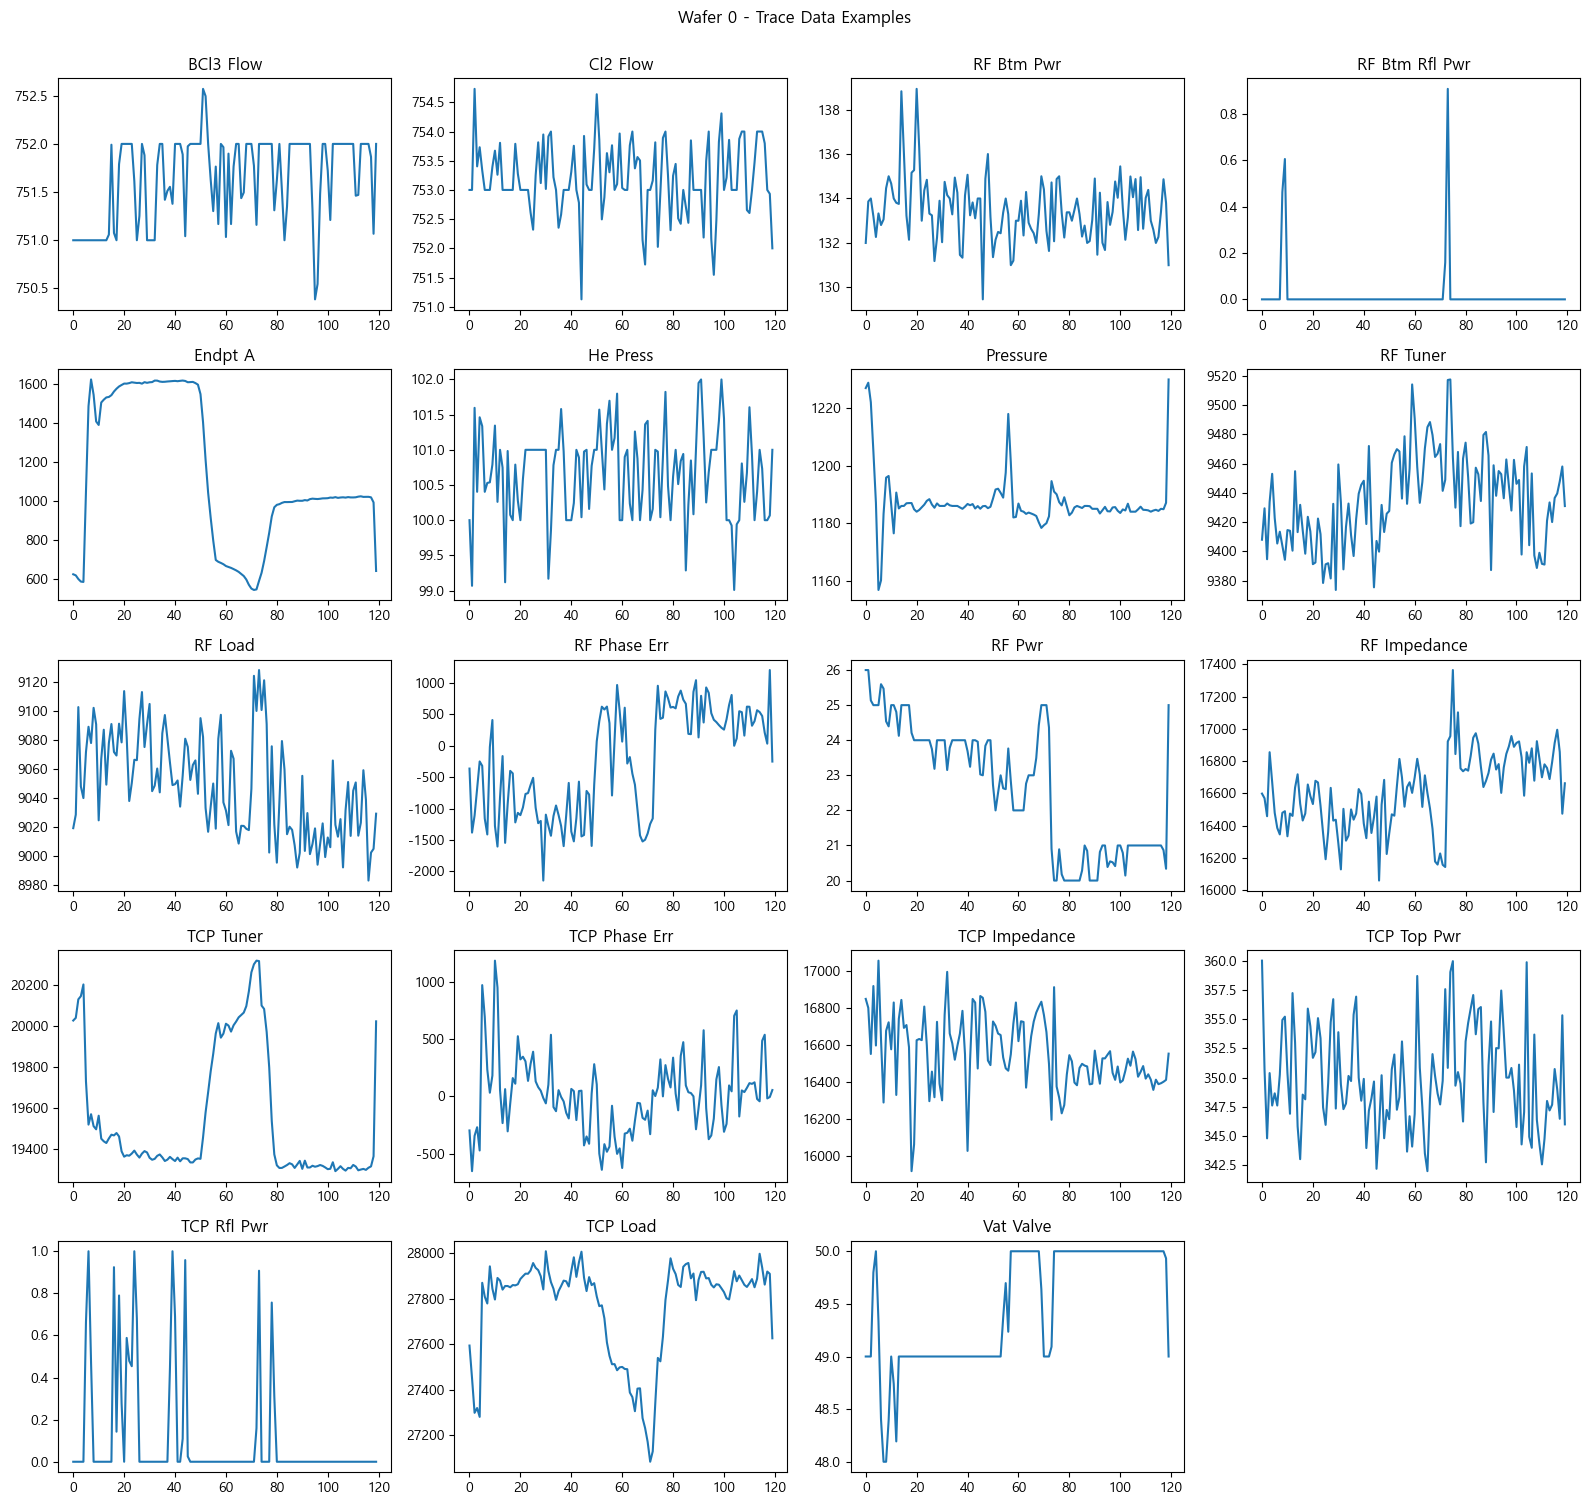

In [7]:
# 0번 웨이퍼의 모든 변수를 시계열로 시각화 (Step Number 제외)
sample = data.loc[0]
cols_to_plot = sample.columns.drop('Step Number')

n_cols = 4  # 한 줄에 그릴 그래프 개수
n_rows = -(-len(cols_to_plot) // n_cols)  # 올림 나눗셈으로 필요한 줄 수 계산

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  

for i, col in enumerate(cols_to_plot):
    axes[i].plot(sample[col].values)
    axes[i].set_title(col)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].axis('off')  # 남는 빈 칸은 숨김

plt.suptitle('Wafer 0 - Trace Data Examples', y=1.0)
plt.tight_layout()
plt.show()

---

## 2) 데이터 전처리

### 2-1) 불필요 변수 제거 및 스케일링

In [8]:
# Step Number는 공정 단계를 나타내는 변수이므로 분석에서 제외

data.drop("Step Number", axis=1, inplace=True)
print("변수 수:", data.shape[1])

변수 수: 19


In [9]:
# 센서마다 단위/범위가 다름
# 모든 변수를 [0,1]로 맞춰 비교와 요약 통계량 해석을 쉽게 하기 위해 MinMax 사용

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
data = pd.DataFrame(scaled, index=data.index, columns=data.columns)
data

,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,0.511361,0.558719,0.395652,0.000000,0.110639,0.369748,0.608123,0.196640,0.407337,0.584226,0.511071,0.491262,0.673741,0.303314,0.625601,0.948498,0.117241,0.428097,0.418719
0,0.511361,0.558719,0.511072,0.000000,0.108881,0.173981,0.612111,0.244356,0.426067,0.389463,0.511071,0.475377,0.680488,0.224203,0.609187,0.608216,0.117241,0.347737,0.418719
0,0.511361,0.803084,0.519391,0.000000,0.103045,0.704845,0.597597,0.166941,0.575148,0.441400,0.449431,0.414323,0.727484,0.292876,0.524820,0.394237,0.117241,0.262535,0.418719
0,0.511361,0.615658,0.469999,0.000000,0.098897,0.454404,0.561168,0.253813,0.465046,0.523174,0.439856,0.632181,0.735533,0.309597,0.649136,0.597793,0.117241,0.274316,0.485574
0,0.511361,0.661922,0.412289,0.000000,0.098303,0.676626,0.522854,0.296819,0.449049,0.605907,0.439856,0.530532,0.765205,0.264398,0.540313,0.496628,0.117241,0.252597,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.515734,0.590747,0.375895,0.000000,0.100687,0.694263,0.608123,0.106291,0.140509,0.890995,0.511071,0.317789,0.065995,0.296368,0.495968,0.327956,0.117241,0.878083,0.586207
128,0.522537,0.476868,0.441404,0.000000,0.100172,0.667808,0.608123,0.078312,0.177058,0.907634,0.552364,0.294897,0.085142,0.396483,0.504925,0.607539,0.117241,0.853797,0.586207
128,0.530635,0.526690,0.543306,0.386555,0.099644,0.579625,0.606470,0.161595,0.122218,0.811244,0.554758,0.383547,0.107355,0.485057,0.524888,0.751623,0.117241,0.847535,0.586207
128,0.530635,0.672598,0.581260,0.806723,0.099827,0.539060,0.604674,0.239814,0.047686,0.710199,0.511071,0.478747,0.123333,0.492870,0.536195,0.646779,0.139901,0.836582,0.586207


In [12]:
from sklearn.preprocessing import StandardScaler
# 센서마다 단위/범위가 다름
# 모든 변수를 [0,1]로 맞춰 비교와 요약 통계량 해석을 쉽게 하기 위해 MinMax 사용

Std = StandardScaler()
Standard = Std.fit_transform(data)
data2 = pd.DataFrame(Standard, index=data.index, columns=data.columns)
data2

,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,-0.302750,-0.365059,-0.991652,-0.136400,-0.852357,-1.033278,0.877293,-1.115972,0.233046,0.186919,-0.019121,0.034411,1.592433,-0.775058,1.498946,2.732658,-0.552859,-0.970271,-0.745528
0,-0.302750,-0.365059,0.442450,-0.136400,-0.859865,-2.553313,0.946756,-0.595157,0.420147,-0.937540,-0.019121,-0.073864,1.628050,-1.728636,1.266916,0.323741,-0.552859,-1.418750,-0.745528
0,-0.302750,2.450160,0.545809,-0.136400,-0.884788,1.568585,0.693935,-1.440130,1.909368,-0.637682,-0.348828,-0.490033,1.876127,-0.900868,0.074288,-1.191056,-0.552859,-1.894253,-0.745528
0,-0.302750,0.290914,-0.067883,-0.136400,-0.902497,-0.375965,0.059379,-0.491932,0.809519,-0.165564,-0.400045,0.994974,1.918619,-0.699323,1.831634,0.249954,-0.552859,-1.828506,0.038690
0,-0.302750,0.823893,-0.784934,-0.136400,-0.905034,1.349481,-0.608031,-0.022526,0.649725,0.312097,-0.400045,0.302092,2.075248,-1.244138,0.293293,-0.466211,-0.552859,-1.949716,0.236808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,-0.201784,0.003926,-1.237129,-0.136400,-0.894855,1.486421,0.877293,-2.102113,-2.432380,1.958047,-0.019121,-1.148051,-1.615699,-0.858773,-0.333573,-1.660266,-0.552859,1.541046,1.219144
128,-0.044727,-1.308020,-0.423179,-0.136400,-0.897053,1.281011,0.877293,-2.407503,-2.067281,2.054113,0.201751,-1.304091,-1.514625,0.347985,-0.206945,0.318953,-0.552859,1.405511,1.219144
128,0.142247,-0.734044,0.842965,4.043122,-0.899307,0.596310,0.848506,-1.498474,-2.615099,1.497606,0.214555,-0.699817,-1.397371,1.415640,0.075253,1.338945,-0.552859,1.370564,1.219144
128,0.142247,0.946888,1.314539,8.586082,-0.898529,0.281348,0.817217,-0.644729,-3.359625,0.914222,-0.019121,-0.050894,-1.313028,1.509823,0.235085,0.596738,0.025398,1.309434,1.219144


---

## 3) Trace Data → 머신러닝 입력 데이터로 변환

### 요약 통계량(Summary Statistics) 후보

> 시계열 데이터를 1행으로 요약할 때 사용할 수 있는 **통계량 후보**
>
> | 통계량 | 설명 | 적합한 데이터 특성 |
> |:---:|:---|:---|
> | **Mean** (평균) | 구간의 전반적인 수준 | 안정적인 센서, 전체 경향 파악 |
> | **Std** (표준편차) | 값의 흩어진 정도 | 진동, 불안정한 센서 |
> | **Variance** (분산) | 변동성의 크기 | Std와 유사, 제곱 스케일 |
> | **Min** (최솟값) | 구간 내 최저점 | 하한 이탈 감지 |
> | **Max** (최댓값) | 구간 내 최고점 | 상한 이탈 감지 |
> | **Range** (범위) | Max - Min | 값의 변동 폭 |
> | **Q25** (1사분위) | 하위 25% 지점 | 분포의 하단 특성 |
> | **Q50** (중앙값) | 하위 50% 지점 | 이상치에 강건한 중심값 |
> | **Q75** (3사분위) | 하위 75% 지점 | 분포의 상단 특성 |

### 3-1) 전체 구간 요약 (Simple Summary)

> 각 제품의 **전체 시계열**을 변수별로 요약하여 1행으로 만드는 방법
> - 장점: 구현이 간단
> - 단점: 시간에 따른 변화 패턴 정보가 사라짐

In [11]:
# 예시: 0번 웨이퍼의 변수별 평균
data.loc[0].mean()

BCl3 Flow         0.523757
Cl2 Flow          0.585083
RF Btm Pwr        0.486355
RF Btm Rfl Pwr    0.017787
Endpt A           0.272718
He Press          0.510136
Pressure          0.523068
RF Tuner          0.256533
RF Load           0.467918
RF Phase Err      0.603699
RF Pwr            0.271868
RF Impedance      0.501563
TCP Tuner         0.422124
TCP Phase Err     0.371361
TCP Impedance     0.526252
TCP Top Pwr       0.583803
TCP Rfl Pwr       0.129778
TCP Load          0.524479
Vat Valve         0.458380
dtype: float64

In [13]:
# 전체 웨이퍼에 대해 Mean, Std로 요약
data_summary = []
for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        temp_summary.append(temp[col].mean())  # 해당 변수의 평균
        temp_summary.append(temp[col].std())   # 해당 변수의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수*2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × 2개 통계량)")

요약 데이터 크기: (129, 38)
→ 129개 웨이퍼 × (19개 변수 × 2개 통계량)


In [14]:
# 컬럼명 생성 (각 원본 변수마다 Mean, Std 두 개씩)
cols = []
for col in data.columns:
    cols.extend([col + '_Mean', col + '_Std'])  # 예: 'RF Btm Pwr_Mean', 'RF Btm Pwr_Std'

# numpy 배열을 DataFrame으로 변환 + 컬럼명 지정
simple_summary = pd.DataFrame(data_summary, columns=cols)
simple_summary

,BCl3 Flow_Mean,BCl3 Flow_Std,Cl2 Flow_Mean,Cl2 Flow_Std,RF Btm Pwr_Mean,RF Btm Pwr_Std,RF Btm Rfl Pwr_Mean,RF Btm Rfl Pwr_Std,Endpt A_Mean,Endpt A_Std,...,TCP Impedance_Mean,TCP Impedance_Std,TCP Top Pwr_Mean,TCP Top Pwr_Std,TCP Rfl Pwr_Mean,TCP Rfl Pwr_Std,TCP Load_Mean,TCP Load_Std,Vat Valve_Mean,Vat Valve_Std
0,0.523757,0.008694,0.585083,0.086170,0.486355,0.087460,0.017787,0.108112,0.272718,0.119195,...,0.526252,0.066211,0.583803,0.156939,0.129778,0.030836,0.524479,0.121741,0.458380,0.046214
1,0.525246,0.007329,0.578094,0.077257,0.474518,0.073812,0.010014,0.090705,0.278572,0.125736,...,0.522100,0.066667,0.556310,0.143814,0.130369,0.031106,0.530764,0.130548,0.457037,0.045342
2,0.522982,0.007903,0.589235,0.085635,0.470380,0.077469,0.000000,0.000000,0.285295,0.129797,...,0.526595,0.065073,0.543097,0.141925,0.133736,0.035531,0.534498,0.138545,0.457430,0.044085
3,0.524711,0.007350,0.581554,0.081651,0.458877,0.078458,0.000000,0.000000,0.286315,0.132098,...,0.516816,0.067512,0.587066,0.127076,0.134368,0.035763,0.525254,0.125728,0.458075,0.043920
4,0.524918,0.008056,0.578598,0.081402,0.468353,0.060809,0.000000,0.000000,0.289958,0.133271,...,0.520427,0.061924,0.558137,0.165919,0.131732,0.031512,0.533673,0.129399,0.460063,0.044095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.526524,0.006913,0.581367,0.074842,0.485240,0.084821,0.000000,0.000000,0.114010,0.066861,...,0.494755,0.064159,0.573907,0.135505,0.138013,0.037801,0.717750,0.155592,0.383861,0.040661
125,0.524627,0.008594,0.607918,0.082623,0.476118,0.074254,0.000000,0.000000,0.109602,0.066323,...,0.510733,0.076942,0.585410,0.156046,0.138900,0.039384,0.712200,0.146260,0.457260,0.043819
126,0.525995,0.008824,0.579498,0.080450,0.478591,0.090028,0.020448,0.131562,0.101489,0.057687,...,0.522362,0.061403,0.572267,0.141153,0.137701,0.037578,0.775177,0.133637,0.653859,0.088332
127,0.524423,0.008035,0.589779,0.075219,0.480371,0.070346,0.032073,0.144075,0.102761,0.066044,...,0.509995,0.063144,0.546312,0.150696,0.131782,0.031609,0.798606,0.154819,0.370109,0.043247


---

### 3-2) 구간별 요약 (Step-based Summary)

> 시계열을 **누적 구간으로 나누어** 각 구간별로 요약하는 방법
>
> 예시: 120개 시점을 6개 누적 구간으로 나누기
> ```
> step_list = [20, 40, 60, 80, 100, -1]
> ```
> | 구간 | 시점 범위 | 설명 |
> |:---:|:---:|:---|
> | Step 0 | 0 ~ 19 | 처음 20개 시점 (공정 초기) |
> | Step 1 | 0 ~ 39 | 처음 40개 시점까지 누적 |
> | Step 2 | 0 ~ 59 | 처음 60개 시점까지 누적 |
> | Step 3 | 0 ~ 79 | 처음 80개 시점까지 누적 |
> | Step 4 | 0 ~ 99 | 처음 100개 시점까지 누적 |
> | Step 5 | 0 ~ 끝 | 전체 시점 (전 구간 누적) |
>
> 매 구간마다 이전 구간을 포함해서 범위가 점점 넓어지는 방식 
> - 공정이 진행될수록 누적된 패턴이 어떻게 변화하는지 포착할 수 있음

In [15]:
step_list = [20, 40, 60, 80, 100, -1]

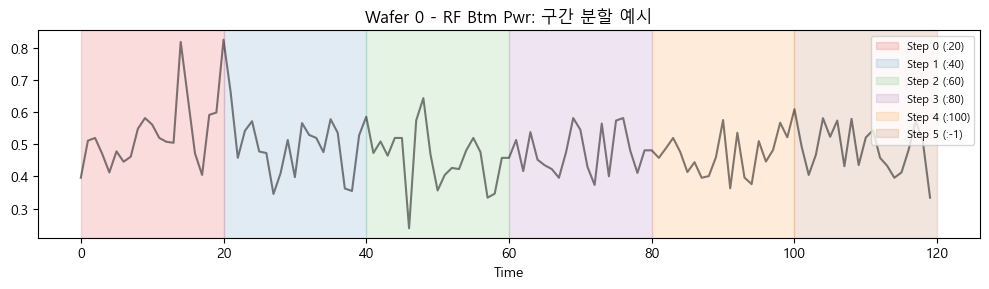

In [16]:
# 구간별 요약 시각화: 0번 웨이퍼의 'RF Btm Pwr' 변수
sample = data.loc[0]['RF Btm Pwr']

plt.figure(figsize=(10, 3))
plt.plot(range(len(sample)), sample.values, color='black', alpha=0.5)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
prev = 0
for i, step in enumerate(step_list):
    end = step if step != -1 else len(sample)
    plt.axvspan(prev, end, alpha=0.15, color=colors[i], label=f'Step {i} (:{step})')
    prev = end
plt.title('Wafer 0 - RF Btm Pwr: 구간 분할 예시')
plt.xlabel('Time')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# 구간별(누적) Mean, Std 요약
data_summary = []

for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        for step in step_list:  # 누적 구간별로 반복 (0~step 시점까지)
            segment = temp[col][:step]  # 해당 구간(0부터 step까지)의 데이터 추출
            temp_summary.append(segment.mean())  # 해당 구간의 평균
            temp_summary.append(segment.std())   # 해당 구간의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수 * 구간 수 * 2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × 2개 통계량)")

요약 데이터 크기: (129, 228)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 2개 통계량)


In [18]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        cols.extend([f'{col}_Step{step_num}_Mean', f'{col}_Step{step_num}_Std'])

step_summary = pd.DataFrame(data_summary, columns=cols)
step_summary

,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,BCl3 Flow_Step2_Mean,BCl3 Flow_Step2_Std,BCl3 Flow_Step3_Mean,BCl3 Flow_Step3_Std,BCl3 Flow_Step4_Mean,BCl3 Flow_Step4_Std,...,Vat Valve_Step1_Mean,Vat Valve_Step1_Std,Vat Valve_Step2_Mean,Vat Valve_Step2_Std,Vat Valve_Step3_Mean,Vat Valve_Step3_Std,Vat Valve_Step4_Mean,Vat Valve_Step4_Std,Vat Valve_Step5_Mean,Vat Valve_Step5_Std
0,0.514171,0.006546,0.518257,0.008290,0.521678,0.009264,0.522723,0.008836,0.522999,0.009010,...,0.414251,0.030215,0.421745,0.032326,0.437456,0.042431,0.450457,0.046040,0.458714,0.046265
1,0.522067,0.008294,0.523654,0.007533,0.524707,0.007389,0.525234,0.007503,0.524809,0.007404,...,0.413881,0.025357,0.419505,0.027042,0.435486,0.039984,0.448881,0.044730,0.457359,0.045396
2,0.516406,0.006926,0.519751,0.008012,0.520790,0.007964,0.522061,0.008073,0.522744,0.008073,...,0.418596,0.025935,0.421839,0.026129,0.436084,0.038157,0.449360,0.043289,0.457756,0.044126
3,0.519630,0.007844,0.522347,0.007636,0.523258,0.007469,0.523997,0.007343,0.525106,0.007122,...,0.418438,0.026445,0.423376,0.027838,0.437069,0.038439,0.450148,0.043246,0.458406,0.043955
4,0.517492,0.007893,0.521257,0.009289,0.523646,0.008709,0.523193,0.008381,0.524665,0.008052,...,0.418455,0.026349,0.425698,0.031000,0.440042,0.040296,0.452526,0.043880,0.460411,0.044116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.524744,0.007581,0.526354,0.006979,0.526343,0.006902,0.526340,0.007060,...,0.348997,0.030392,0.353612,0.033984,0.366432,0.039593,0.376890,0.041143,0.383568,0.040706
125,0.516010,0.007314,0.519901,0.009486,0.522353,0.009399,0.523869,0.008883,0.524751,0.008446,...,0.418526,0.026465,0.423516,0.028084,0.435864,0.037599,0.449184,0.042952,0.457584,0.043860
126,0.516797,0.009776,0.521907,0.010027,0.523983,0.009812,0.525025,0.009428,0.525394,0.009058,...,0.576689,0.059000,0.586582,0.058876,0.608761,0.064567,0.637748,0.081985,0.655835,0.086001
127,0.515062,0.008607,0.520018,0.009273,0.521862,0.009014,0.523163,0.008580,0.524385,0.008210,...,0.339937,0.034586,0.341954,0.031949,0.345804,0.031980,0.360387,0.040931,0.369701,0.043197


---

### 3-3) 다양한 통계량을 활용한 구간별 요약

> **다양한 통계량을 조합**하면 더 풍부한 정보를 머신러닝 모델에 제공할 수 있음

In [19]:
# 사용할 통계량 정의
stat_funcs = {
    'Mean': lambda x: x.mean(),
    'Std': lambda x: x.std(),
    'Min': lambda x: x.min(),
    'Max': lambda x: x.max(),
    'Range': lambda x: x.max() - x.min(),
    'Q25': lambda x: x.quantile(0.25),
    'Q50': lambda x: x.quantile(0.50),
    'Q75': lambda x: x.quantile(0.75),
}

print("사용할 통계량:", list(stat_funcs.keys()))

사용할 통계량: ['Mean', 'Std', 'Min', 'Max', 'Range', 'Q25', 'Q50', 'Q75']


In [20]:
step_list = [20, 40, 60, 80, 100, -1]

data_summary = []
for wafer_idx in data.index.unique():
    temp = data.loc[wafer_idx]
    temp_summary = []
    for col in temp.columns:
        for step in step_list:
            segment = temp[col][:step]
            for func in stat_funcs.values():
                temp_summary.append(func(segment))
    data_summary.append(temp_summary)

data_summary = np.array(data_summary)
print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × {len(stat_funcs)}개 통계량)")

요약 데이터 크기: (129, 912)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 8개 통계량)


In [21]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        for stat_name in stat_funcs.keys():
            cols.append(f'{col}_Step{step_num}_{stat_name}')

full_summary = pd.DataFrame(data_summary, columns=cols)

print("최종 변수 수:", full_summary.shape[1])
full_summary

최종 변수 수: 912


,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step0_Min,BCl3 Flow_Step0_Max,BCl3 Flow_Step0_Range,BCl3 Flow_Step0_Q25,BCl3 Flow_Step0_Q50,BCl3 Flow_Step0_Q75,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,...,Vat Valve_Step4_Q50,Vat Valve_Step4_Q75,Vat Valve_Step5_Mean,Vat Valve_Step5_Std,Vat Valve_Step5_Min,Vat Valve_Step5_Max,Vat Valve_Step5_Range,Vat Valve_Step5_Q25,Vat Valve_Step5_Q50,Vat Valve_Step5_Q75
0,0.514171,0.006546,0.511361,0.530635,0.019274,0.511361,0.511361,0.511644,0.518257,0.008290,...,0.418719,0.502463,0.458714,0.046265,0.334975,0.502463,0.167488,0.418719,0.477129,0.502463
1,0.522067,0.008294,0.511361,0.530635,0.019274,0.513386,0.522375,0.530635,0.523654,0.007533,...,0.418719,0.502463,0.457359,0.045396,0.334975,0.502463,0.167488,0.418719,0.464462,0.502463
2,0.516406,0.006926,0.511361,0.530635,0.019274,0.511361,0.511361,0.522982,0.519751,0.008012,...,0.418719,0.502463,0.457756,0.044126,0.334975,0.502463,0.167488,0.418719,0.443350,0.502463
3,0.519630,0.007844,0.511361,0.530635,0.019274,0.511361,0.518245,0.527477,0.522347,0.007636,...,0.418719,0.502463,0.458406,0.043955,0.334975,0.502463,0.167488,0.418719,0.453202,0.502463
4,0.517492,0.007893,0.511361,0.530635,0.019274,0.511361,0.511361,0.523104,0.521257,0.009289,...,0.418719,0.502463,0.460411,0.044116,0.334975,0.502463,0.167488,0.418719,0.486981,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.511361,0.530635,0.019274,0.511361,0.521808,0.529056,0.524744,0.007581,...,0.374384,0.418719,0.383568,0.040706,0.334975,0.418719,0.083744,0.334975,0.418719,0.418719
125,0.516010,0.007314,0.511361,0.530635,0.019274,0.511361,0.511361,0.518285,0.519901,0.009486,...,0.418719,0.502463,0.457584,0.043860,0.334975,0.502463,0.167488,0.418719,0.450387,0.502463
126,0.516797,0.009776,0.495150,0.533699,0.038549,0.514424,0.514424,0.522968,0.521907,0.010027,...,0.588670,0.687368,0.655835,0.086001,0.418719,0.753695,0.334975,0.586207,0.669951,0.753695
127,0.515062,0.008607,0.495164,0.530635,0.035471,0.511361,0.512333,0.518488,0.520018,0.009273,...,0.334975,0.418719,0.369701,0.043197,0.251232,0.418719,0.167488,0.334975,0.334975,0.418719


> **참고**
> - 통계량을 많이 사용하면 변수 수가 급격히 늘어남
> - 변수가 너무 많으면 **차원의 저주**가 발생할 수 있으므로, 이후 mRMR, Boruta 등의 **차원 축소** 기법을 적용하는 것이 좋음

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 지금까지 모든 변수에 Mean, Std 같은 통계량을 똑같이 적용해서 요약했는데
변수마다 분포 특성이 다르다는 걸 알게 되었습니다.

AI와 상의하여 변수별 분포 특성을 분석하는 코드를 작성하고 변수마다 적합한 통계량을 추천받아 요약해 보세요.

=== 변수별 분포 특성 요약 ===


,평균,표준편차,변동계수(CV),왜도,첨도,범위(Range),IQR,이상치비율,고유값비율
변수,,,,,,,,,
BCl3 Flow,0.5245,0.0433,0.0826,-1.3635,119.4497,1.0,0.0136,0.0099,0.0244
Cl2 Flow,0.5904,0.0868,0.1470,-0.1301,0.8104,1.0,0.0996,0.0198,0.0444
RF Btm Pwr,0.4755,0.0805,0.1693,-0.0981,1.4113,1.0,0.1097,0.0101,0.0788
RF Btm Rfl Pwr,0.0126,0.0925,7.3314,8.2173,70.4022,1.0,0.0000,0.0247,0.0070
Endpt A,0.3103,0.2342,0.7548,0.9197,-0.0475,1.0,0.3334,0.0023,0.8598
He Press,0.5028,0.1288,0.2561,0.1742,-0.1598,1.0,0.1993,0.0005,0.0266
Pressure,0.5578,0.0574,0.1029,0.8060,5.3835,1.0,0.0916,0.0120,0.2940
RF Tuner,0.2989,0.0916,0.3065,0.8133,4.2029,1.0,0.1130,0.0166,0.5879
RF Load,0.3840,0.1001,0.2607,0.5085,2.0350,1.0,0.1289,0.0172,0.6355


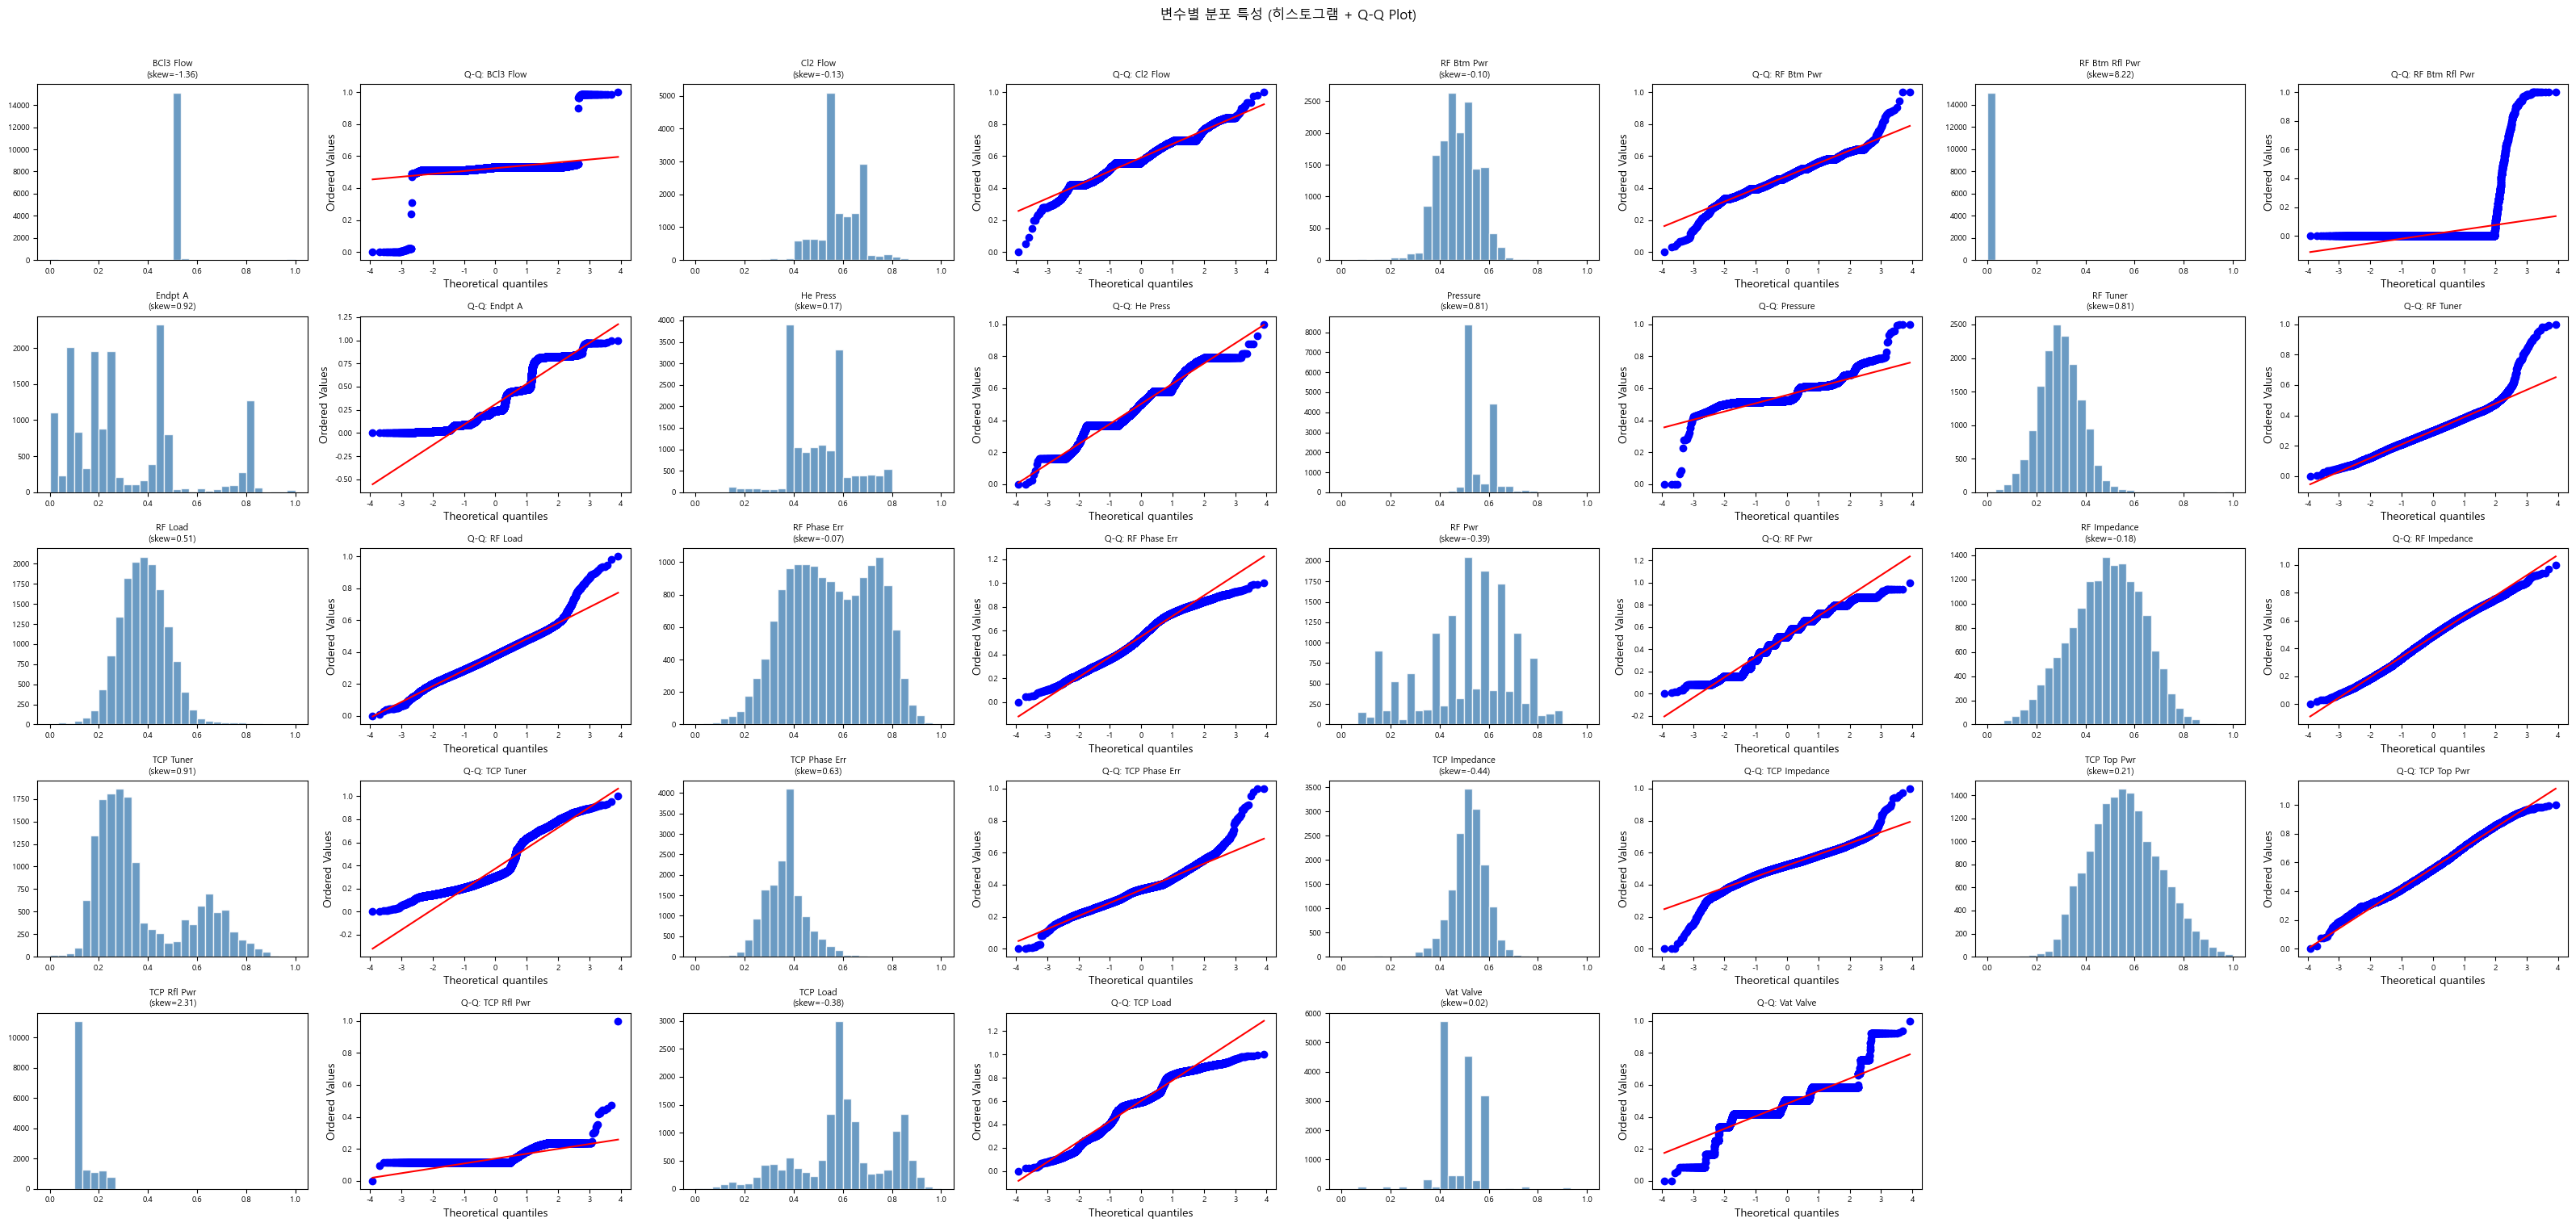

In [22]:
from scipy import stats

# ── 1) 변수별 분포 특성 분석 ──────────────────────────────────
# 모든 웨이퍼·시점 값을 변수별로 모아 분포 지표 계산

def analyze_distribution(data, outlier_iqr=1.5):
    """변수별 분포 특성을 수치화하여 DataFrame으로 반환"""
    records = []

    for col in data.columns:
        values = data[col].dropna().values
        q1, q50, q3 = np.percentile(values, [25, 50, 75])
        iqr = q3 - q1
        lower, upper = q1 - outlier_iqr * iqr, q3 + outlier_iqr * iqr
        outlier_ratio = np.mean((values < lower) | (values > upper))

        mean_val = values.mean()
        std_val = values.std()
        cv = std_val / (mean_val + 1e-10)          # 변동계수 (상대적 변동성)
        value_range = values.max() - values.min()

        records.append({
            '변수': col,
            '평균': mean_val,
            '표준편차': std_val,
            '변동계수(CV)': cv,
            '왜도': stats.skew(values),
            '첨도': stats.kurtosis(values),         # 정규분포 기준 0
            '범위(Range)': value_range,
            'IQR': iqr,
            '이상치비율': outlier_ratio,
            '고유값비율': len(np.unique(values)) / len(values),  # 거의 상수면 → 0에 가까움
        })

    dist_profile = pd.DataFrame(records).set_index('변수')
    return dist_profile

dist_profile = analyze_distribution(data)
print("=== 변수별 분포 특성 요약 ===")
display(dist_profile.round(4))

# 시각화: 변수별 히스토그램 + Q-Q plot
n_cols = 4
n_vars = len(data.columns)
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(4 * n_cols * 2, 3 * n_rows))
axes = axes.reshape(n_rows, n_cols, 2)

for i, col in enumerate(data.columns):
    r, c = divmod(i, n_cols)
    values = data[col].dropna().values

    # 히스토그램
    axes[r, c, 0].hist(values, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[r, c, 0].set_title(f'{col}\n(skew={stats.skew(values):.2f})', fontsize=8)
    axes[r, c, 0].tick_params(labelsize=7)

    # Q-Q plot (정규성 확인)
    stats.probplot(values, dist="norm", plot=axes[r, c, 1])
    axes[r, c, 1].set_title(f'Q-Q: {col}', fontsize=8)
    axes[r, c, 1].tick_params(labelsize=7)

# 빈 칸 숨기기
for i in range(n_vars, n_rows * n_cols):
    r, c = divmod(i, n_cols)
    axes[r, c, 0].axis('off')
    axes[r, c, 1].axis('off')

plt.suptitle('변수별 분포 특성 (히스토그램 + Q-Q Plot)', y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# ── 2) 변수별 적합 통계량 추천 ──────────────────────────────

STAT_FUNCS = {
    'Mean':  lambda x: x.mean(),
    'Std':   lambda x: x.std(),
    'Min':   lambda x: x.min(),
    'Max':   lambda x: x.max(),
    'Range': lambda x: x.max() - x.min(),
    'Q25':   lambda x: x.quantile(0.25),
    'Q50':   lambda x: x.quantile(0.50),
    'Q75':   lambda x: x.quantile(0.75),
}

def recommend_stats(row):
  """
  분포 특성에 따라 변수마다 사용할 통계량을 추천.
  규칙은 휴리스틱이며, 실습 목적상 해석 가능한 기준을 사용.
  """
  recommended = []

  # (1) 거의 상수인 변수 → Mean만으로 충분
  if row['고유값비율'] < 0.05 or row['범위(Range)'] < 0.05:
      return ['Mean']

  # (2) 왜도가 크면 → 중앙값·분위수 중심
  if abs(row['왜도']) > 1.0:
      recommended += ['Q50', 'Q25', 'Q75']
  elif abs(row['왜도']) > 0.5:
      recommended += ['Q50', 'Mean']
  else:
      recommended.append('Mean')

  # (3) 변동성이 크면 → Std, Range 추가
  if row['변동계수(CV)'] > 0.3:
      recommended += ['Std', 'Range']

  # (4) 이상치가 많으면 → Min, Max 추가 (극값 포착)
  if row['이상치비율'] > 0.05:
      recommended += ['Min', 'Max']

  # (5) 첨도가 높으면(꼬리가 두꺼움) → 분위수 강화
  if row['첨도'] > 1.0:
      recommended += ['Q25', 'Q75']

  # 중복 제거 (순서 유지)
  recommended = list(dict.fromkeys(recommended))
  return recommended

# 변수별 추천 결과
stat_recommendations = {}
for col in dist_profile.index:
    stat_recommendations[col] = recommend_stats(dist_profile.loc[col])

recommend_df = pd.DataFrame({
    '추천_통계량': [', '.join(v) for v in stat_recommendations.values()],
    '통계량_개수': [len(v) for v in stat_recommendations.values()],
}, index=dist_profile.index)

print("=== 변수별 추천 통계량 ===")
display(recommend_df)

# 전체 통계량 사용 빈도
from collections import Counter
freq = Counter(s for stats_list in stat_recommendations.values() for s in stats_list)
print("\n통계량별 추천 횟수:", dict(freq))

=== 변수별 추천 통계량 ===


,추천_통계량,통계량_개수
변수,,
BCl3 Flow,Mean,1
Cl2 Flow,Mean,1
RF Btm Pwr,"Mean, Q25, Q75",3
RF Btm Rfl Pwr,Mean,1
Endpt A,"Q50, Mean, Std, Range",4
He Press,Mean,1
Pressure,"Q50, Mean, Q25, Q75",4
RF Tuner,"Q50, Mean, Std, Range, Q25, Q75",6
RF Load,"Q50, Mean, Q25, Q75",4



통계량별 추천 횟수: {'Mean': 19, 'Q25': 6, 'Q75': 6, 'Q50': 6, 'Std': 6, 'Range': 6}


In [24]:
# ── 3) 추천 통계량만으로 요약 DataFrame 생성 ──────────────────

step_list = [20, 40, 60, 80, 100, -1]

def slice_segment(series, step):
    """step=-1이면 전체, 아니면 0~step-1 구간"""
    return series if step == -1 else series.iloc[:step]

rows = []
col_names = []

for wafer_idx in data.index.unique():
    wafer_data = data.loc[wafer_idx]
    row = []

    for col in data.columns:
        for step_num, step in enumerate(step_list):
            segment = slice_segment(wafer_data[col], step)

            for stat_name in stat_recommendations[col]:
                row.append(STAT_FUNCS[stat_name](segment))

    rows.append(row)

# 컬럼명 생성 (변수 × 구간 × 해당 변수의 추천 통계량)
for col in data.columns:
    for step_num in range(len(step_list)):
        for stat_name in stat_recommendations[col]:
            col_names.append(f'{col}_Step{step_num}_{stat_name}')

adaptive_summary = pd.DataFrame(rows, columns=col_names)

print(f"기존 full_summary 예상 크기: {len(data.columns)} × {len(step_list)} × 8 = {len(data.columns) * len(step_list) * 8}")
print(f"adaptive_summary 실제 크기:   {adaptive_summary.shape}")
print(f"→ 변수 수 감소: {len(data.columns) * len(step_list) * 8 - adaptive_summary.shape[1]}개 feature 절약")
adaptive_summary.head()

기존 full_summary 예상 크기: 19 × 6 × 8 = 912
adaptive_summary 실제 크기:   (129, 294)
→ 변수 수 감소: 618개 feature 절약


,BCl3 Flow_Step0_Mean,BCl3 Flow_Step1_Mean,BCl3 Flow_Step2_Mean,BCl3 Flow_Step3_Mean,BCl3 Flow_Step4_Mean,BCl3 Flow_Step5_Mean,Cl2 Flow_Step0_Mean,Cl2 Flow_Step1_Mean,Cl2 Flow_Step2_Mean,Cl2 Flow_Step3_Mean,...,TCP Load_Step2_Mean,TCP Load_Step3_Mean,TCP Load_Step4_Mean,TCP Load_Step5_Mean,Vat Valve_Step0_Mean,Vat Valve_Step1_Mean,Vat Valve_Step2_Mean,Vat Valve_Step3_Mean,Vat Valve_Step4_Mean,Vat Valve_Step5_Mean
0,0.514171,0.518257,0.521678,0.522723,0.522999,0.523757,0.603915,0.588909,0.591380,0.587633,...,0.542594,0.493330,0.513297,0.524479,0.409782,0.414251,0.421745,0.437456,0.450457,0.458380
1,0.522067,0.523654,0.524707,0.525234,0.524809,0.525246,0.558185,0.570196,0.572974,0.574095,...,0.554942,0.492790,0.518446,0.530764,0.409043,0.413881,0.419505,0.435486,0.448881,0.457037
2,0.516406,0.519751,0.520790,0.522061,0.522744,0.522982,0.667912,0.626394,0.598438,0.593594,...,0.561174,0.495645,0.518859,0.534498,0.418473,0.418596,0.421839,0.436084,0.449360,0.457430
3,0.519630,0.522347,0.523258,0.523997,0.525106,0.524711,0.591578,0.574466,0.569494,0.573473,...,0.545009,0.488484,0.510199,0.525254,0.418156,0.418438,0.423376,0.437069,0.450148,0.458075
4,0.517492,0.521257,0.523646,0.523193,0.524665,0.524918,0.599407,0.586951,0.589739,0.576779,...,0.549569,0.495251,0.521424,0.533673,0.418191,0.418455,0.425698,0.440042,0.452526,0.460063


In [25]:
# stat_recommendations, STAT_FUNCS 가 이미 정의되어 있다고 가정

rows = []
col_names = []

# 컬럼명 먼저 생성 (변수 × 해당 변수의 추천 통계량)
for col in data.columns:
    for stat_name in stat_recommendations[col]:
        col_names.append(f'{col}_{stat_name}')

# 웨이퍼별 요약
for wafer_idx in data.index.unique():
    wafer_data = data.loc[wafer_idx]   # (120, 변수수)
    row = []

    for col in data.columns:
        series = wafer_data[col]       # 해당 웨이퍼의 전체 시계열
        for stat_name in stat_recommendations[col]:
            row.append(STAT_FUNCS[stat_name](series))

    rows.append(row)

adaptive_simple_summary = pd.DataFrame(rows, columns=col_names, index=data.index.unique())

print("요약 데이터 크기:", adaptive_simple_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × (변수별 추천 통계량 합)")
adaptive_simple_summary.head()

요약 데이터 크기: (129, 49)
→ 129개 웨이퍼 × (변수별 추천 통계량 합)


,BCl3 Flow_Mean,Cl2 Flow_Mean,RF Btm Pwr_Mean,RF Btm Pwr_Q25,RF Btm Pwr_Q75,RF Btm Rfl Pwr_Mean,Endpt A_Q50,Endpt A_Mean,Endpt A_Std,Endpt A_Range,...,TCP Phase Err_Mean,TCP Phase Err_Q25,TCP Phase Err_Q75,TCP Impedance_Mean,TCP Impedance_Q25,TCP Impedance_Q75,TCP Top Pwr_Mean,TCP Rfl Pwr_Mean,TCP Load_Mean,Vat Valve_Mean
0,0.523757,0.585083,0.486355,0.425417,0.536028,0.017787,0.234494,0.272718,0.119195,0.339204,...,0.371361,0.323165,0.397289,0.526252,0.479291,0.576805,0.583803,0.129778,0.524479,0.458380
1,0.525246,0.578094,0.474518,0.427366,0.519391,0.010014,0.237118,0.278572,0.125736,0.364732,...,0.363794,0.314586,0.392797,0.522100,0.492045,0.559294,0.556310,0.130369,0.530764,0.457037
2,0.522982,0.589235,0.470380,0.423857,0.515751,0.000000,0.239725,0.285295,0.129797,0.376252,...,0.368044,0.333844,0.397043,0.526595,0.492818,0.572472,0.543097,0.133736,0.534498,0.457430
3,0.524711,0.581554,0.458877,0.395652,0.519001,0.000000,0.241970,0.286315,0.132098,0.383829,...,0.352352,0.304035,0.394458,0.516816,0.470235,0.567944,0.587066,0.134368,0.525254,0.458075
4,0.524918,0.578598,0.468353,0.422427,0.518091,0.000000,0.243518,0.289958,0.133271,0.387973,...,0.367975,0.309615,0.398607,0.520427,0.478484,0.562340,0.558137,0.131732,0.533673,0.460063
